# Plot STATE MI Results — All Datasets

Collects MI values from disk for all (dataset, size, quality, algorithm) combinations,
checks completeness, fits noise scaling laws, and visualizes results.

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']

# Seeds/signals mirror analysis/2026-04-16_14-49_compute_state_all_datasets.py
EXPECTED = {
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'signals': ['ng_idx'],
        'seeds': [1404, 2303, 2701],
    },
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'signals': ['protein_counts'],
        'seeds': [42, 2303, 2701],
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'signals': ['clone'],
        'seeds': [42, 1404, 2701],
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'signals': ['author_day'],
        'seeds': [42],
    },
}

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def _read_mi(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

# Build expected paths for ALL algorithms (including State)
expected_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, sig, sd in product(cfg['sizes'], cfg['qualities'], ALGOS, cfg['signals'], cfg['seeds']):
        suffix = '_geneformer' if algo == 'Geneformer' else ''
        stem = f'Y_{sig}_{q}{suffix}'
        mi_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
        expected_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'signal': sig, 'seed': sd, 'path': str(mi_path),
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected: {len(df_expected)}')

# Check existence in parallel
with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

# Read MI values for found files
df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['mi_value'] = list(tqdm(pool.map(_read_mi, df_found['path']),
                                     total=len(df_found), desc='Reading MI'))

# Final dataframe
out_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_value']
df_results = df_found[out_cols].sort_values(out_cols[:-1]).reset_index(drop=True)
print(f'Collected {len(df_results)} MI values (NaN: {df_results["mi_value"].isna().sum()})')

Total expected: 5000


Scanning: 100%|██████████| 5000/5000 [00:00<00:00, 491931.22it/s]

Found: 4437, Missing: 563



Reading MI: 100%|██████████| 4437/4437 [00:00<00:00, 28644.93it/s]

Collected 4437 MI values (NaN: 0)


In [ ]:
# Completeness table: found / expected / missing per dataset × algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
display(pivot_wide)

found                                    expected       \
algorithm Geneformer  PCA RandomProjection SCVI State Geneformer  PCA   
dataset                                                                 
PBMC             300  300              300  300   100        300  300   
larry            300  300              300  300   100        300  300   
merfish          300  300              300  300   137        300  300   
shendure         100  100              100  100   100        100  100   

                                         missing                            \
algorithm RandomProjection SCVI State Geneformer PCA RandomProjection SCVI   
dataset                                                                      
PBMC                   300  300   300          0   0                0    0   
larry                  300  300   300          0   0                0    0   
merfish                300  300   300          0   0                0    0   
shendure               100  100   100          0   0                0    0   

                 
algorithm State  
dataset          
PBMC        200  
larry       200  
merfish     163  
shendure      0

In [ ]:
# Detailed State completeness: rows=size, cols=quality, values=seeds found (0 or 1)
# One table per dataset
df_state_exp = df_expected[df_expected['algorithm'] == 'State'].copy()

for ds in EXPECTED:
    sub = df_state_exp[df_state_exp['dataset'] == ds]
    grid = sub.groupby(['size', 'quality'])['exists'].sum().astype(int).unstack('quality', fill_value=0)
    grid.columns = [f'{q:.4g}' for q in grid.columns]
    grid.index.name = 'size'
    total_found = grid.values.sum()
    total_expected = len(sub)
    print(f'\n{ds}  —  State completeness ({total_found}/{total_expected})')
    display(grid)


merfish  —  State completeness (137/300)


,0.02725,0.04066,0.06068,0.09055,0.1351,0.2016,0.3009,0.4491,0.6701,1
size,,,,,,,,,,
100,1,1,1,1,1,2,2,2,1,2
203,1,2,1,2,1,2,1,1,2,2
414,2,2,1,1,1,2,1,1,1,2
843,2,2,1,1,2,2,2,2,1,2
1716,2,1,1,2,1,2,1,1,1,1
3494,2,1,2,2,1,2,1,1,2,1
7113,1,2,2,1,1,1,1,1,2,1
14480,1,1,1,2,1,1,1,1,1,1
29475,2,1,1,1,1,1,2,2,2,1



PBMC  —  State completeness (100/300)


,0.001235,0.002598,0.005468,0.01151,0.02422,0.05097,0.1073,0.2258,0.4752,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
215,1,1,1,1,1,1,1,1,1,1
464,1,1,1,1,1,1,1,1,1,1
1000,1,1,1,1,1,1,1,1,1,1
2154,1,1,1,1,1,1,1,1,1,1
4641,1,1,1,1,1,1,1,1,1,1
10000,1,1,1,1,1,1,1,1,1,1
21544,1,1,1,1,1,1,1,1,1,1
46415,1,1,1,1,1,1,1,1,1,1



larry  —  State completeness (100/300)


,0.003876,0.007183,0.01331,0.02467,0.04573,0.08476,0.1571,0.2911,0.5396,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
215,1,1,1,1,1,1,1,1,1,1
464,1,1,1,1,1,1,1,1,1,1
1000,1,1,1,1,1,1,1,1,1,1
2154,1,1,1,1,1,1,1,1,1,1
4641,1,1,1,1,1,1,1,1,1,1
10000,1,1,1,1,1,1,1,1,1,1
21544,1,1,1,1,1,1,1,1,1,1
46415,1,1,1,1,1,1,1,1,1,1



shendure  —  State completeness (100/100)


,0.004,0.007387,0.01364,0.0252,0.04654,0.08595,0.1587,0.2932,0.5415,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
359,1,1,1,1,1,1,1,1,1,1
1291,1,1,1,1,1,1,1,1,1,1
4641,1,1,1,1,1,1,1,1,1,1
16681,1,1,1,1,1,1,1,1,1,1
59948,1,1,1,1,1,1,1,1,1,1
215443,1,1,1,1,1,1,1,1,1,1
774263,1,1,1,1,1,1,1,1,1,1
2782559,1,1,1,1,1,1,1,1,1,1


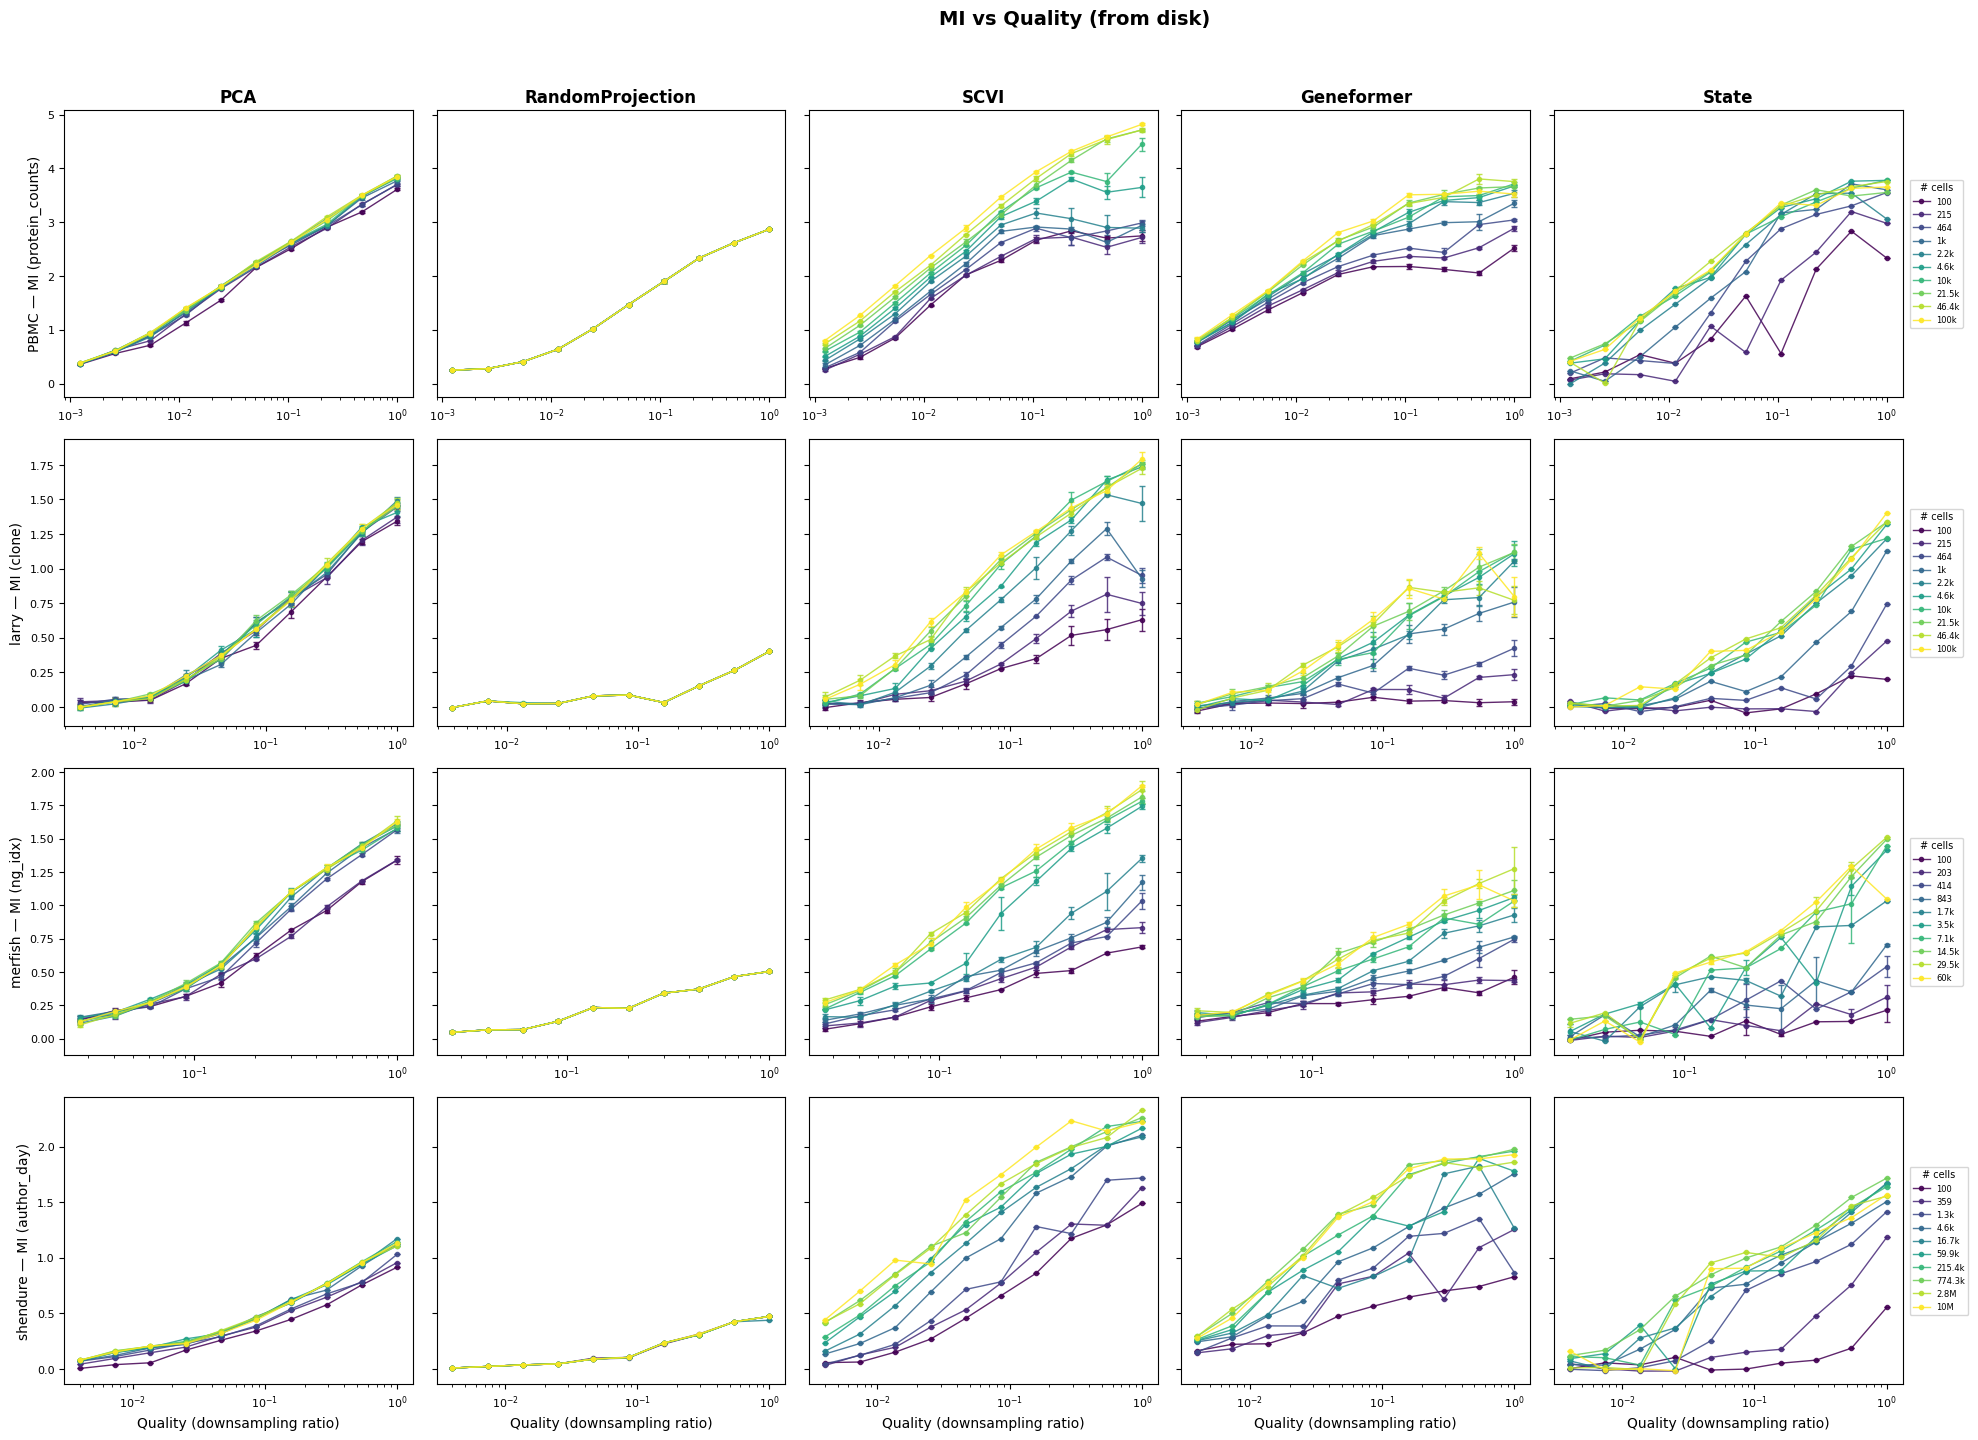

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ALGO_ORDER = ['PCA', 'RandomProjection', 'SCVI', 'Geneformer', 'State']

def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

def plot_mi_vs_quality(df):
    """Plot MI vs quality: rows=(dataset, signal), cols=algorithm, curves=size.
    Per-dataset color norm and a per-row legend rendered on the right — built
    from handles collected across every column so the legend always renders
    even if the rightmost algo has no data for that row."""
    all_ds_sig = sorted(set(zip(df['dataset'], df['signal'])))
    algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
    n_rows = len(all_ds_sig)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    # Share y-axis within each row
    for i in range(n_rows):
        for j in range(1, n_cols):
            axes[i, j].sharey(axes[i, 0])

    cmap = plt.cm.viridis

    # Per-dataset size norms
    ds_norms = {}
    for ds, _ in all_ds_sig:
        sizes = sorted(df[df['dataset'] == ds]['size'].unique())
        if sizes:
            ds_norms[ds] = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes))

    for i, (ds, sig) in enumerate(all_ds_sig):
        norm = ds_norms.get(ds)
        # Gather one handle per size for this row, picking whichever column
        # supplies it first (sorted by size so labels stay ordered).
        row_handles: dict[float, tuple] = {}
        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo) & (df['signal'] == sig)]

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
                ax.set_xscale('log')
            else:
                for sz in sorted(sub['size'].unique()):
                    color = cmap(norm(sz))
                    sz_df = sub[sub['size'] == sz]
                    agg = sz_df.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                    agg = agg.sort_values('quality')
                    agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                    errbar = ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                                          marker='o', markersize=3, linewidth=1, capsize=2,
                                          color=color, alpha=0.85, label=_fmt_size(sz))
                    if sz not in row_handles:
                        row_handles[sz] = (errbar[0], _fmt_size(sz))
                ax.set_xscale('log')

            if i == n_rows - 1:
                ax.set_xlabel('Quality (downsampling ratio)', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{ds} — MI ({sig})', fontsize=10)
            if i == 0:
                ax.set_title(algo, fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=8)
            if j > 0:
                ax.tick_params(labelleft=False)

        # Per-row legend on the rightmost axis (always renders if the row has data).
        if row_handles:
            sizes_sorted = sorted(row_handles.keys())
            handles = [row_handles[s][0] for s in sizes_sorted]
            labels  = [row_handles[s][1] for s in sizes_sorted]
            axes[i, n_cols - 1].legend(
                handles, labels, title='# cells', fontsize=6, title_fontsize=7,
                loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                frameon=True, framealpha=0.8,
            )

    fig.suptitle('MI vs Quality (from disk)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
    plt.show()
    return fig

fig_quality = plot_mi_vs_quality(df_results)

In [ ]:
# ── Fit noise scaling laws ──────────────────────────────────────────────
# For each (dataset, algorithm, signal, size) group, fit:
#   I(u) = I_max - 0.5 * log2( (1 + u/u_bar) / (u/u_bar + 2^(-2*I_max)) )
# where u = quality (downsampling fraction, proportional to UMIs/cell).

from lmfit import Model
import warnings

def info_scaling(u, u_bar, I_max):
    u = np.asarray(u, dtype=float)
    u_bar = np.asarray(u_bar, dtype=float)
    I_max = np.asarray(I_max, dtype=float)
    eps = 1e-12
    u_bar_safe = np.where(u_bar == 0, eps, u_bar)
    r = u / u_bar_safe
    num = 1 + r
    den = r + 2 ** (-2 * I_max)
    den = np.where(den == 0, eps, den)
    ratio = np.clip(num / den, eps, None)
    return I_max - 0.5 * np.log2(ratio)

def fit_one_group(u_values, mi_values):
    """Fit the noise-scaling model to one (dataset, algo, signal, size) slice.
    Returns fitted params, stderrs, average uncertainty, and R²."""
    model = Model(info_scaling)
    params = model.make_params(u_bar=0.05, I_max=1.0)
    params['u_bar'].min = 1e-12
    params['I_max'].min = 0
    try:
        result = model.fit(mi_values, params, u=u_values)
        # Coefficient of determination (R²) on the quality-averaged MI values.
        y_pred = np.asarray(result.best_fit, dtype=float)
        y_true = np.asarray(mi_values, dtype=float)
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = (1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                y_unc = result.eval_uncertainty(params=result.params, u=u_values, sigma=2)
            except Exception:
                y_unc = np.zeros_like(u_values)
        return {
            'u_bar':     result.params['u_bar'].value,
            'I_max':     result.params['I_max'].value,
            'u_bar_err': result.params['u_bar'].stderr,
            'I_max_err': result.params['I_max'].stderr,
            'avg_unc':   np.mean(np.abs(y_unc)),
            'r2':        r2,
            'success':   True,
        }
    except Exception:
        return {k: np.nan for k in
                ['u_bar', 'I_max', 'u_bar_err', 'I_max_err', 'avg_unc', 'r2']} | {'success': False}

# --- run fits ---
fit_records = []
groups = df_results.groupby(['dataset', 'algorithm', 'signal', 'size'])
for (ds, algo, sig, sz), grp in tqdm(groups, desc='Fitting noise scaling'):
    if len(grp) < 3:
        continue
    agg = grp.groupby('quality')['mi_value'].mean().reset_index().sort_values('quality')
    res = fit_one_group(agg['quality'].values, agg['mi_value'].values)
    fit_records.append({
        'dataset': ds, 'algorithm': algo, 'signal': sig, 'size': sz, **res,
    })

df_fits = pd.DataFrame(fit_records)
n_ok = df_fits['success'].sum()
print(f'Fitted {n_ok}/{len(df_fits)} groups successfully')
display(df_fits[df_fits['success']].head(10))

Fitting noise scaling: 100%|██████████| 200/200 [00:02<00:00, 97.03it/s] 

Fitted 200/200 groups successfully


,dataset,algorithm,signal,size,u_bar,I_max,u_bar_err,I_max_err,avg_unc,r2,success
0,PBMC,Geneformer,protein_counts,100,0.016100,2.290559,0.003267,0.064111,0.133943,0.957556,True
1,PBMC,Geneformer,protein_counts,215,0.027237,2.603684,0.005411,0.071959,0.139332,0.967143,True
2,PBMC,Geneformer,protein_counts,464,0.036243,2.839408,0.008177,0.088049,0.162680,0.963569,True
3,PBMC,Geneformer,protein_counts,1000,0.054428,3.207440,0.006864,0.054187,0.092794,0.990795,True
4,PBMC,Geneformer,protein_counts,2154,0.089084,3.531814,0.009131,0.048075,0.073508,0.995393,True
5,PBMC,Geneformer,protein_counts,4641,0.110354,3.677966,0.010281,0.045246,0.065388,0.996658,True
6,PBMC,Geneformer,protein_counts,10000,0.102454,3.692623,0.010693,0.050352,0.074368,0.995654,True
7,PBMC,Geneformer,protein_counts,21544,0.098830,3.764843,0.006963,0.034036,0.050863,0.998037,True
8,PBMC,Geneformer,protein_counts,46415,0.112623,3.852320,0.011448,0.050106,0.072285,0.996232,True
9,PBMC,Geneformer,protein_counts,100000,0.079219,3.713038,0.012007,0.071170,0.112642,0.990133,True


In [ ]:
# ── State R² ranking: worst → best ──────────────────────────────────────
# One row per (dataset, signal, size) State fit. Sorted ascending by R² so
# the worst fits appear at the top — quick way to spot (size, signal) cells
# where the noise-scaling model struggles.

state_fits = (
    df_fits[(df_fits['algorithm'] == 'State') & df_fits['success']]
    [['dataset', 'signal', 'size', 'r2', 'u_bar', 'I_max', 'u_bar_err', 'I_max_err']]
    .sort_values('r2', ascending=True, na_position='first')
    .reset_index(drop=True)
)

# Attach the number of quality points that fed each fit (useful context
# when R² looks odd — partial runs can give misleadingly high or low R²).
n_qs = (df_results[df_results['algorithm'] == 'State']
        .groupby(['dataset', 'signal', 'size'])['quality'].nunique()
        .rename('n_qualities'))
state_fits = state_fits.join(n_qs, on=['dataset', 'signal', 'size'])

print(f'State fits ranked worst → best: {len(state_fits)} rows')
display(
    state_fits.style
        .format({'r2': '{:.4f}', 'u_bar': '{:.4f}', 'I_max': '{:.3f}',
                 'u_bar_err': '{:.4f}', 'I_max_err': '{:.3f}'})
        .background_gradient(subset=['r2'], cmap='RdYlGn', vmin=0, vmax=1)
)


State fits ranked worst → best: 40 rows


,dataset,signal,size,r2,u_bar,I_max,u_bar_err,I_max_err,n_qualities
0,merfish,ng_idx,100,0.6707,1.1381,0.361,1.4439,0.238,10
1,merfish,ng_idx,843,0.7512,1.3762,1.014,1.7637,0.505,10
2,larry,clone,100,0.7608,2.8261,0.637,7.3804,0.883,10
3,larry,clone,215,0.7897,44799.6708,7.470,11654264063.6089,187634.631,10
4,merfish,ng_idx,203,0.7939,1.5218,0.590,1.9459,0.370,10
5,merfish,ng_idx,414,0.8087,0.9089,0.756,0.8826,0.295,10
6,PBMC,protein_counts,100,0.8100,0.7792,2.999,1.1525,0.815,10
7,merfish,ng_idx,3494,0.8254,63006.9515,9.091,1310255151.1730,15000.077,10
8,shendure,author_day,100,0.8301,44551.6404,7.606,7002710969.1889,113372.752,10
9,merfish,ng_idx,1716,0.8641,1.7694,1.624,2.0480,0.588,10


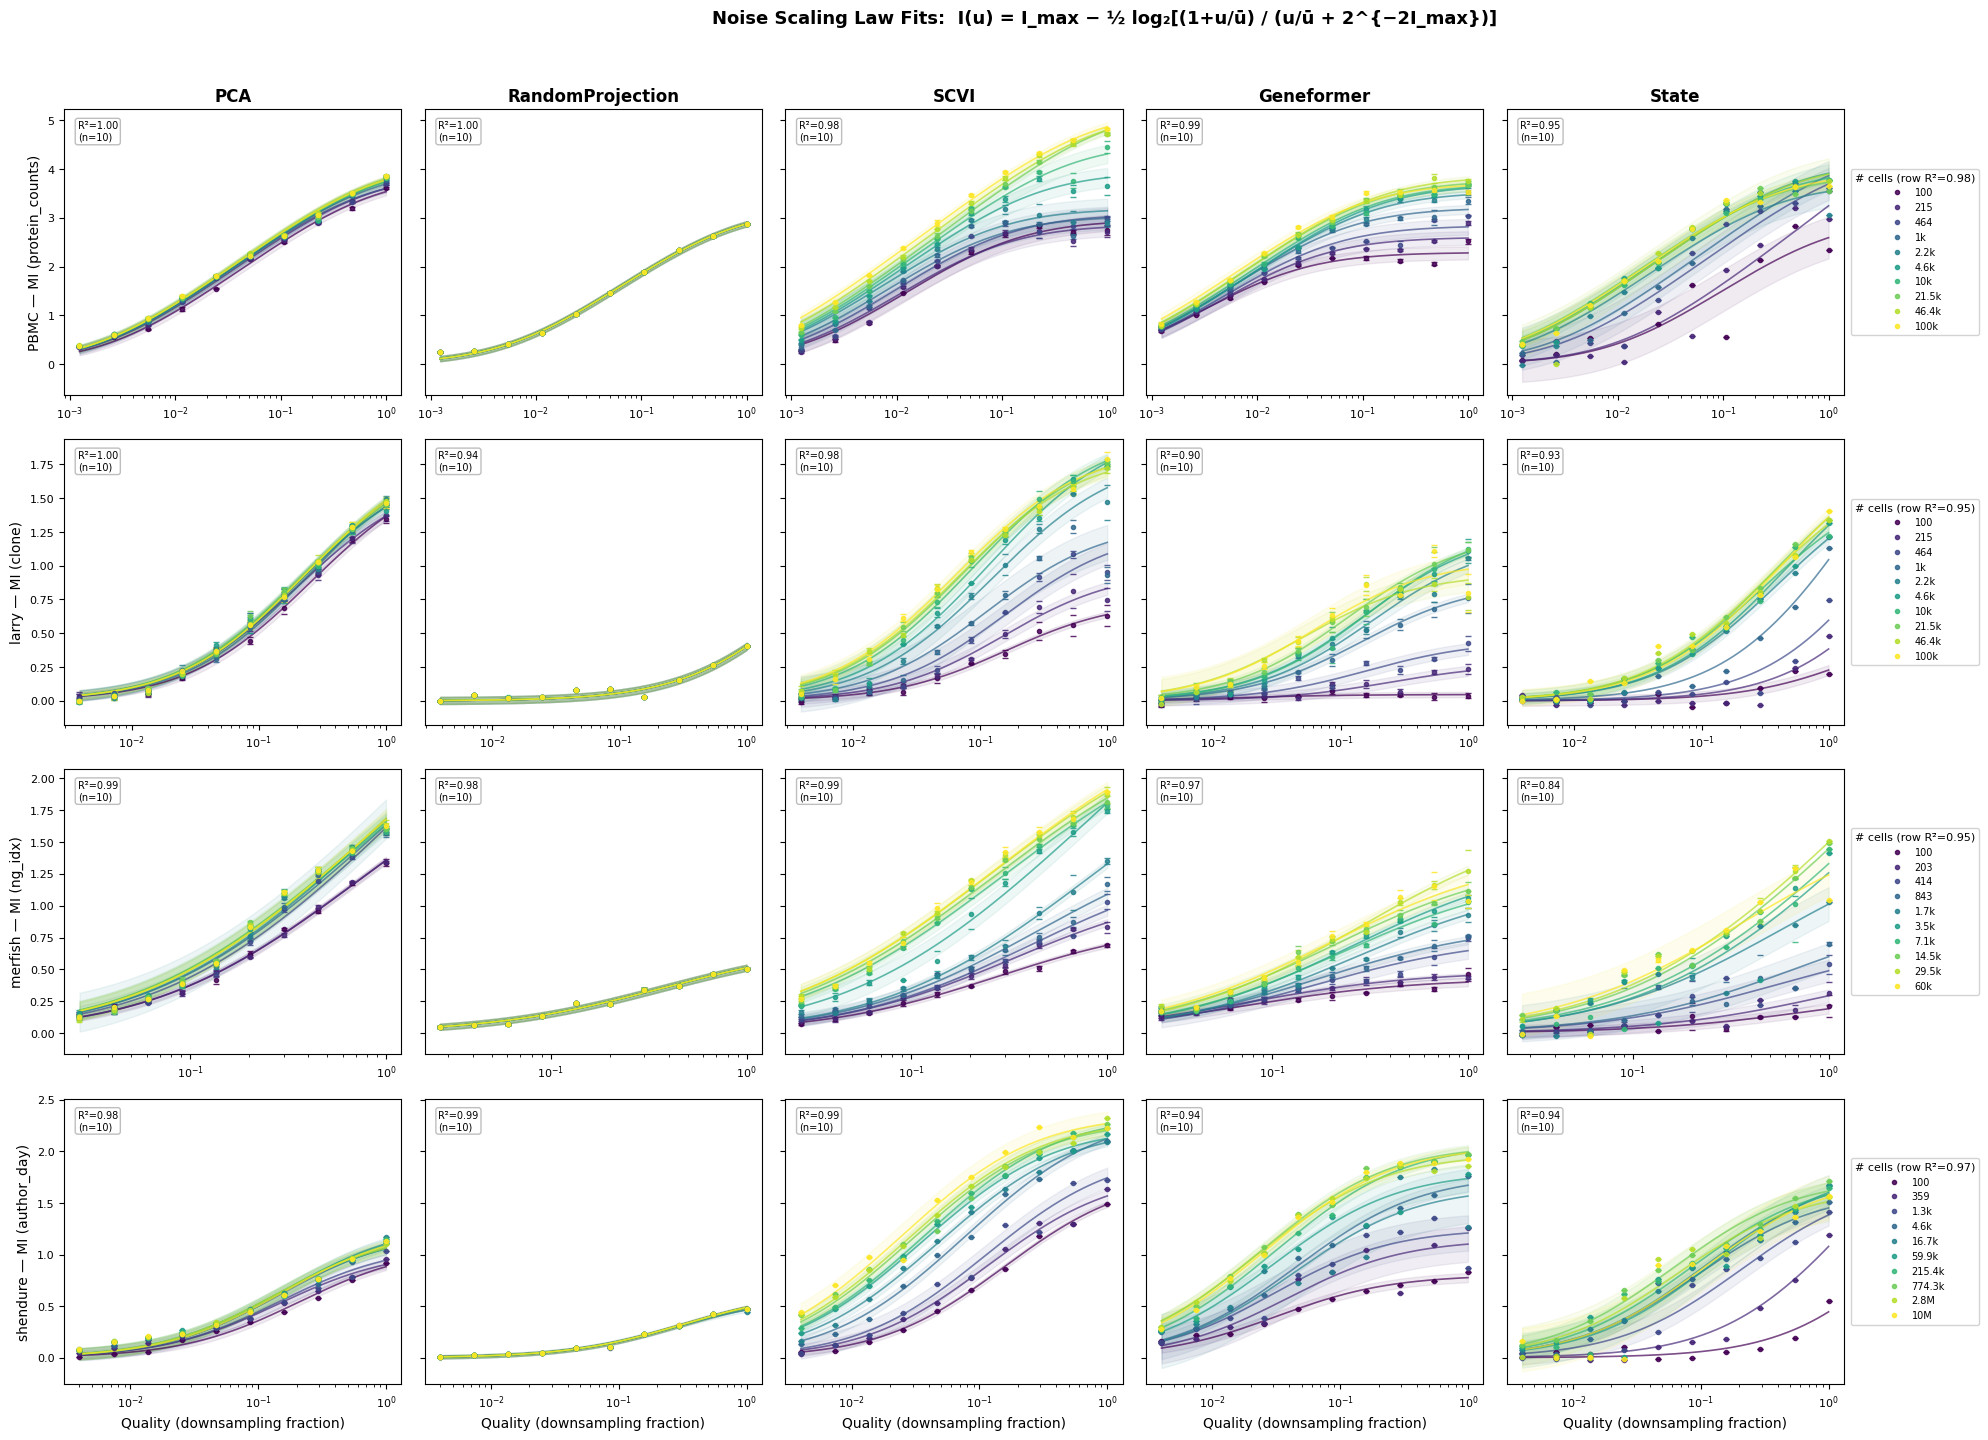

In [ ]:
# ── Visualize noise scaling fits ────────────────────────────────────────
# Rows = (dataset, signal) pairs from EXPECTED only, Cols = algorithms.
# Each subplot shows one fitted curve per size; the legend to the right of
# each row reports cell counts, with aggregate R² in the legend title and a
# per-subplot mean R² in the top-left text box.

import matplotlib.colors as mcolors

# Only plot (dataset, signal) combinations listed in EXPECTED — guarantees
# we don't accidentally render ghost rows from leftover on-disk results.
expected_pairs = {(ds, sig) for ds, cfg in EXPECTED.items() for sig in cfg['signals']}

df_ok = df_fits[df_fits['success']].copy()
df_ok = df_ok[df_ok.apply(lambda r: (r['dataset'], r['signal']) in expected_pairs, axis=1)]

rowkeys = sorted(set(zip(df_ok['dataset'], df_ok['signal'])))
algo_order = [a for a in ALGO_ORDER if a in df_ok['algorithm'].unique()]
n_rows = len(rowkeys)
n_cols = len(algo_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols + 2.2, 3.5 * n_rows + 0.8),
                         squeeze=False)

# share y within each row
for i in range(n_rows):
    for j in range(1, n_cols):
        axes[i, j].sharey(axes[i, 0])

cmap = plt.cm.viridis

for i, (ds, sig) in enumerate(rowkeys):
    # per-dataset size color norm
    sizes_ds = sorted(df_ok[df_ok['dataset'] == ds]['size'].unique())
    if not sizes_ds:
        continue
    norm = mcolors.LogNorm(vmin=min(sizes_ds), vmax=max(sizes_ds))

    # Track handles/labels from every algo in this row so the legend can
    # render even when the rightmost algo has no fits for this (ds, sig).
    row_handles: dict[float, tuple] = {}
    r2_values: list[float] = []

    for j, algo in enumerate(algo_order):
        ax = axes[i, j]
        sub_fits = df_ok[(df_ok['dataset'] == ds) &
                         (df_ok['algorithm'] == algo) &
                         (df_ok['signal'] == sig)]
        sub_data = df_results[(df_results['dataset'] == ds) &
                              (df_results['algorithm'] == algo) &
                              (df_results['signal'] == sig)]

        if sub_fits.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
            ax.set_xscale('log')
        else:
            subplot_r2 = []
            for _, row in sub_fits.iterrows():
                sz = row['size']
                color = cmap(norm(sz))
                u_bar, I_max, r2 = row['u_bar'], row['I_max'], row.get('r2', np.nan)
                if not np.isnan(r2):
                    subplot_r2.append(r2)
                    r2_values.append(r2)

                # plot data points
                pts = sub_data[sub_data['size'] == sz]
                agg = pts.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                agg = agg.sort_values('quality')
                agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                errbar = ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                                      marker='o', markersize=3, linewidth=0, capsize=2,
                                      color=color, alpha=0.85, label=_fmt_size(sz))

                # plot fitted curve
                q_range = np.logspace(np.log10(agg['quality'].min()),
                                      np.log10(agg['quality'].max()), 200)
                fitted = info_scaling(q_range, u_bar, I_max)
                ax.plot(q_range, fitted, color=color, lw=1.2, alpha=0.7)

                # uncertainty band (constant approximation from avg_unc)
                if not np.isnan(row['avg_unc']) and row['avg_unc'] <= 0.5:
                    ax.fill_between(q_range,
                                    fitted - row['avg_unc'],
                                    fitted + row['avg_unc'],
                                    color=color, alpha=0.08)

                # row-level legend: cell-count only, keyed by size so later
                # columns don't duplicate the entry (R² is reported in the
                # subplot text box + row legend title, not per-curve).
                if sz not in row_handles:
                    row_handles[sz] = (errbar[0], _fmt_size(sz))

            ax.set_xscale('log')
            # Per-subplot R² summary (mean across sizes) in top-left corner.
            if subplot_r2:
                ax.text(0.04, 0.96,
                        f'R²̄={np.mean(subplot_r2):.2f}\n'
                        f'(n={len(subplot_r2)})',
                        transform=ax.transAxes, va='top', ha='left',
                        fontsize=7, color='black',
                        bbox=dict(boxstyle='round,pad=0.25',
                                  facecolor='white', edgecolor='0.7', alpha=0.85))

        if i == n_rows - 1:
            ax.set_xlabel('Quality (downsampling fraction)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{ds} — MI ({sig})', fontsize=10)
        if i == 0:
            ax.set_title(algo, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)
        if j > 0:
            ax.tick_params(labelleft=False)

    # Row legend: always render, using handles gathered from any column.
    if row_handles:
        sizes_sorted = sorted(row_handles.keys())
        handles = [row_handles[s][0] for s in sizes_sorted]
        labels  = [row_handles[s][1] for s in sizes_sorted]
        row_r2_mean = np.mean(r2_values) if r2_values else np.nan
        title = (f'# cells (row R²̄={row_r2_mean:.2f})'
                 if not np.isnan(row_r2_mean) else '# cells')
        axes[i, n_cols - 1].legend(
            handles, labels, title=title, fontsize=7, title_fontsize=8,
            loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
            frameon=True, framealpha=0.85,
        )

fig.suptitle('Noise Scaling Law Fits:  I(u) = I_max − ½ log₂[(1+u/ū) / (u/ū + 2^{−2I_max})]',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.01, 0.90, 0.96])
plt.show()
